# 2D Ising Model: Temperature Sweep Energy and Magnetisation
This notebook extends my 21st July fixed-temperature Metropolis simulation into a controlled and reproducible temperature sweep. I will be addeding:

1. mean energy per spin versus temperature; and
2. mean absolute magnetisation per spin versus temperature.

Throughout the notebook, the simulation uses $J=1$, $k_B=1$, $B=0$ and periodic boundary conditions. One Monte Carlo sweep is defined here as $L^2$ random single-spin flip attempts.

Only one primary seed is used per temperature, no final confidence interval, susceptibility, specific heat or phase-boundary estimate is claimed here. The raw moments needed for those later calculations are nevertheless saved.

In [1]:
from pathlib import Path
from time import perf_counter
import csv
import json

import matplotlib.pyplot as plt
import numpy as np

# Project-relative paths keep the notebook portable.
OUTPUT_DIR = Path("outputs") / "day22"
DIAGNOSTIC_DIR = OUTPUT_DIR / "diagnostics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)

# Keeping every figure and data file from this notebook in one location.
OUTPUT_DIR = Path("outputs/day22")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

J_DEFAULT = 1.0
B_DEFAULT = 0.0
K_B_DEFAULT = 1.0

# Exact zero-field infinite-square-lattice benchmark for J = k_B = 1.
TC_EXACT = 2.0 / np.log(1.0 + np.sqrt(2.0))

print(f"Output directory: {OUTPUT_DIR}")
print(f"Exact infinite-lattice benchmark: T_c = {TC_EXACT:.9f}")

Output directory: outputs\day22
Exact infinite-lattice benchmark: T_c = 2.269185314


## 1. Physical conventions and finite-size interpretation

**Source:** Tong, *Statistical Physics*, Section 5.2, printed pp. 147–148, for the Ising Hamiltonian and magnetisation. Section 5.2.3, printed p. 154, for the absence of a true singular transition in a finite system. Section 5.3.4, printed pp. 165–166, for the exact square-lattice benchmark.

At zero field,

$
E=-J\sum_{\langle ij\rangle}s_i s_j,
\qquad s_i\in\{-1,+1\},
$

where every nearest-neighbour bond is counted once. The signed magnetisation per spin is

$
m=\frac{1}{L^2}\sum_i s_i.
$

The main finite-system order parameter is $\langle |m|\rangle$. Signed $\langle m\rangle$ is retained as a diagnostic because it shows which symmetry sector the chain occupies.

A periodic square lattice contains $2L^2$ nearest-neighbour bonds. Thus, for $J=1$ and $B=0$, aligned all-up and all-down states have $e=E/L^2=-2$, while an even-$L$ checkerboard has $e=+2$. The line at

$
T_c=\frac{2}{\ln(1+\sqrt{2})}\simeq2.269185
$

is an exact **infinite-lattice benchmark**, not a measured sharp transition for $L=20$. A finite lattice displays a rounded crossover.

## 2. Initial conditions and magnetisation

**Source:** Krauth, *Statistical Mechanics: Algorithms and Computations*, pp. 7–9, for initial-state memory and Markov-chain equilibration.

Random, all-up and all-down starts allow the temperature sweep to use a common documented initial condition while still supporting selected initial-condition checks.

In [2]:
def initialise_grid(
    L: int,
    rng: np.random.Generator,
    mode: str = "random",
) -> np.ndarray:
    """Create an L x L lattice containing only -1 and +1 spins."""
    # The lattice must contain at least four sites for a meaningful square model.
    if L < 2:
        raise ValueError("L must be at least 2.")

    # A random start resembles a high-temperature, disordered configuration.
    if mode == "random":
        return rng.choice((-1, 1), size=(L, L)).astype(np.int8)

    # Ordered starts are useful for testing whether the chain forgets its initial state.
    if mode == "up":
        return np.ones((L, L), dtype=np.int8)

    if mode == "down":
        return -np.ones((L, L), dtype=np.int8)

    raise ValueError("mode must be 'random', 'up', or 'down'.")


def calculate_magnetisation(grid: np.ndarray) -> float:
    """Return the signed magnetisation per spin."""
    if grid.ndim != 2 or grid.shape[0] != grid.shape[1]:
        raise ValueError("grid must be a square two-dimensional array.")
    # np.mean(grid) is exactly sum(s_i) / L^2 for a square spin lattice.
    return float(np.mean(grid))

## 3. The Core Engine: Local Ising Metropolis Update
**Source:** Metropolis *et al.* (1953), Section II, for the acceptance procedure. Krauth, p. 250, Fig. 5.14 and Algorithm 5.7 (`markov-ising`).

For a proposed flip of spin $s_i$, the local energy change is

$$\Delta E = 2J s_i \sum_{j\in\mathrm{nn}(i)} s_j.$$

The move is accepted with probability $\min\left(1,e^{-\Delta E/T}\right)$ because $k_B=1$. Krauth specifically warns that factors of two should be checked on small lattices before larger simulations are trusted.

In [3]:
def local_energy_change(
    grid: np.ndarray,
    i: int,
    j: int,
    J: float = 1.0,
) -> float:
    """Return the energy change produced by flipping grid[i, j]."""
    if grid.ndim != 2 or grid.shape[0] != grid.shape[1]:
        raise ValueError("grid must be a square two-dimensional array.")

    L = grid.shape[0]
    spin = int(grid[i, j])

    # Modulo arithmetic enforces periodic boundary conditions in both directions.
    neighbour_sum = (
        int(grid[(i - 1) % L, j]) +  # Above
        int(grid[(i + 1) % L, j]) +  # Below
        int(grid[i, (j - 1) % L]) +  # Left
        int(grid[i, (j + 1) % L])    # Right
    )

    # Flipping s_i reverses all four bonds connected to that spin.
    return 2.0 * J * spin * neighbour_sum


def attempted_spin_flip(
    grid: np.ndarray,
    i: int,
    j: int,
    T: float,
    rng: np.random.Generator,
    J: float = 1.0,
) -> bool:
    """Attempt one local Metropolis spin flip and report whether it was accepted."""
    if T <= 0.0:
        raise ValueError("T must be positive.")

    # Calculate the local energy cost before changing the lattice.
    delta_E = local_energy_change(grid, i, j, J)

    # Energy-lowering and energy-neutral moves are accepted automatically.
    if delta_E <= 0.0:
        grid[i, j] *= -1
        return True

    # Energy-raising moves are accepted according to the Boltzmann factor.
    acceptance_probability = np.exp(-delta_E / T)
    if rng.random() < acceptance_probability:
        grid[i, j] *= -1
        return True

    # A rejected move leaves the lattice unchanged.
    return False

## 4. The Monte Carlo Sweep
**Source:** Krauth, p. 250, Algorithm 5.7, for random-site single-spin updates.

Krauth's elementary update selects one random site and attempts one spin flip. In this notebook, one Monte Carlo sweep groups $L^2$ such attempts, so every site is selected once *on average*. Random selection means that some sites may be chosen more than once and others not at all during an individual sweep.

In [4]:
def metropolis_sweep(
    grid: np.ndarray,
    T: float,
    rng: np.random.Generator,
    J: float = 1.0,
) -> float:
    """Perform L^2 random attempted flips and return the acceptance fraction."""
    # Prevent accidental use of a non-square array.
    if grid.ndim != 2 or grid.shape[0] != grid.shape[1]:
        raise ValueError("grid must be a square two-dimensional array.")

    L = grid.shape[0]
    accepted = 0

    # One sweep contains exactly one attempted update per site on average.
    for _ in range(grid.size):
        i = int(rng.integers(0, L))
        j = int(rng.integers(0, L))

        # bool is converted to 1 for an accepted move and 0 for a rejected move.
        accepted += int(attempted_spin_flip(grid, i, j, T, rng, J))

    # The acceptance fraction is a useful diagnostic of temperature-dependent dynamics.
    return accepted / grid.size

## 5. Total energy with no bond double counting

**Source:** Tong, printed pp. 147–149, for the nearest-neighbour Hamiltonian and the $Nq/2$ count of distinct bonds; printed pp. 157–158, for the aligned ground states with $E_0=-2N_sJ$.

The total-energy function counts only the right-hand and downward bond from each site:

$
E=-J\sum_{i,j}s_{i,j}
\left[
s_{i,(j+1)\bmod L}
+s_{(i+1)\bmod L,j}
\right].
$

Every periodic bond is therefore counted once, so no final factor of $1/2$ is required. The field term is included in the energy function, but the simulation runner below explicitly requires $B=0$ because the inherited local update is a zero-field implementation.

In [5]:
def calculate_total_energy(
    grid: np.ndarray,
    J: float = 1.0,
    B: float = 0.0,
) -> float:
    """Return total Ising energy with every nearest-neighbour bond counted once."""
    if grid.ndim != 2 or grid.shape[0] != grid.shape[1]:
        raise ValueError("grid must be a square two-dimensional array.")
    if not set(np.unique(grid)).issubset({-1, 1}):
        raise ValueError("grid must contain only -1 and +1 spins.")

    right_products = grid * np.roll(grid, shift=-1, axis=1)
    down_products = grid * np.roll(grid, shift=-1, axis=0)

    interaction_energy = -J * (
        np.sum(right_products, dtype=np.int64)
        + np.sum(down_products, dtype=np.int64)
    )
    field_energy = -B * np.sum(grid, dtype=np.int64)

    return float(interaction_energy + field_energy)


def calculate_energy_per_spin(
    grid: np.ndarray,
    J: float = 1.0,
    B: float = 0.0,
) -> float:
    """Return total energy divided by the number of spins."""
    return calculate_total_energy(grid, J=J, B=B) / grid.size


def calculate_total_energy_reference(
    grid: np.ndarray,
    J: float = 1.0,
    B: float = 0.0,
) -> float:
    """Transparent loop implementation used only for testing."""
    L = grid.shape[0]
    energy = 0.0

    for i in range(L):
        for j in range(L):
            spin = int(grid[i, j])
            energy -= J * spin * int(grid[i, (j + 1) % L])
            energy -= J * spin * int(grid[(i + 1) % L, j])
            energy -= B * spin

    return float(energy)

## 6. Temperature-sweep protocol

**Source:** Krauth, Section 5.1.2, printed pp. 234–236, for thermal averages of energy and magnetisation; printed pp. 250–252, especially Figs. 5.15–5.17, for local dynamics and ordered/disordered behaviour; Tong, printed p. 154, for finite-size rounding.

The debugging grid contains five separated temperatures and is used only for code, shape and gross-physics checks. The main grid is non-uniform: it covers clearly ordered and disordered regimes while placing more points near $T\simeq2.269$, where the finite-system observables are expected to vary most rapidly.

The primary curve uses an independent all-up start at every temperature. This avoids history dependence between neighbouring temperatures and avoids low-temperature coarsening from a random domain mosaic. Random-start checks at $T=1.5$, $T=T_c$ and $T=3.5$ diagnose residual initial-state dependence.

The provisional main protocol retains $L=20$, 1,000 burn-in sweeps and 2,000 production sweeps from 21 July. Energy and magnetisation are recorded after every production sweep. This does not imply that neighbouring measurements are statistically independent.

In [6]:
DEBUG_TEMPERATURES = np.array(
    [1.50, 2.10, TC_EXACT, 2.50, 3.50],
    dtype=float,
)

MAIN_TEMPERATURES = np.array(
    [
        1.50, 1.70, 1.90, 2.05,
        2.10, 2.15, 2.20, 2.23, 2.25,
        TC_EXACT,
        2.29, 2.32, 2.35, 2.40,
        2.50, 2.70, 3.00, 3.50,
    ],
    dtype=float,
)

DEBUG_PROTOCOL = {
    "L": 8,
    "J": 1.0,
    "B": 0.0,
    "k_B": 1.0,
    "n_burn_sweeps": 50,
    "n_production_sweeps": 100,
    "storage_interval": 1,
    "initial_state": "up",
    "n_replicates": 1,
    "base_seed": 21900,
}

MAIN_PROTOCOL = {
    "L": 20,
    "J": 1.0,
    "B": 0.0,
    "k_B": 1.0,
    "n_burn_sweeps": 1000,
    "n_production_sweeps": 2000,
    "storage_interval": 1,
    "initial_state": "up",
    "n_replicates": 1,
    "base_seed": 22000,
}


def validate_temperature_grid(temperatures: np.ndarray) -> np.ndarray:
    """Validate and return a one-dimensional increasing temperature grid."""
    temperatures = np.asarray(temperatures, dtype=float)

    if temperatures.ndim != 1:
        raise ValueError("temperatures must be one-dimensional.")
    if temperatures.size == 0:
        raise ValueError("temperatures must not be empty.")
    if not np.all(np.isfinite(temperatures)):
        raise ValueError("temperatures must contain only finite values.")
    if np.any(temperatures <= 0.0):
        raise ValueError("all temperatures must be positive.")
    if not np.all(np.diff(temperatures) > 0.0):
        raise ValueError(
            "temperatures must be strictly increasing with no duplicates."
        )

    return temperatures


def make_seed_matrix(
    base_seed: int,
    n_replicates: int,
    n_temperatures: int,
) -> np.ndarray:
    """Assign one distinct integer seed to every replicate-temperature run."""
    if base_seed < 0:
        raise ValueError("base_seed must be non-negative.")
    if n_replicates < 1:
        raise ValueError("n_replicates must be at least one.")
    if n_temperatures < 1:
        raise ValueError("n_temperatures must be at least one.")

    seeds = base_seed + np.arange(
        n_replicates * n_temperatures,
        dtype=np.int64,
    )
    return seeds.reshape(n_replicates, n_temperatures)


def protocol_run_arguments(protocol: dict) -> dict:
    """Return only arguments accepted by the simulation functions."""
    names = (
        "L",
        "J",
        "B",
        "k_B",
        "n_burn_sweeps",
        "n_production_sweeps",
        "storage_interval",
        "initial_state",
    )
    return {name: protocol[name] for name in names}


DEBUG_TEMPERATURES = validate_temperature_grid(DEBUG_TEMPERATURES)
MAIN_TEMPERATURES = validate_temperature_grid(MAIN_TEMPERATURES)

DEBUG_SEEDS = make_seed_matrix(
    DEBUG_PROTOCOL["base_seed"],
    DEBUG_PROTOCOL["n_replicates"],
    DEBUG_TEMPERATURES.size,
)
MAIN_SEEDS = make_seed_matrix(
    MAIN_PROTOCOL["base_seed"],
    MAIN_PROTOCOL["n_replicates"],
    MAIN_TEMPERATURES.size,
)

main_proposal_count = (
    MAIN_PROTOCOL["n_replicates"]
    * MAIN_TEMPERATURES.size
    * (
        MAIN_PROTOCOL["n_burn_sweeps"]
        + MAIN_PROTOCOL["n_production_sweeps"]
    )
    * MAIN_PROTOCOL["L"] ** 2
)

print(f"Number of main temperatures: {MAIN_TEMPERATURES.size}")
print(f"Main seed-matrix shape: {MAIN_SEEDS.shape}")
print(f"Primary proposal count: {main_proposal_count:,}")
print(f"Main seed range: {MAIN_SEEDS[0, 0]} to {MAIN_SEEDS[0, -1]}")

Number of main temperatures: 18
Main seed-matrix shape: (1, 18)
Primary proposal count: 21,600,000
Main seed range: 22000 to 22017


## 7. Fixed-temperature burn-in and production sampling

**Source:** Krauth, printed pp. 234–236, for thermal energy and magnetisation moments; printed pp. 250–251, for local Metropolis sampling and correlated trajectories.

The 21 July fixed-temperature loop is extended rather than replaced. It now records energy, magnetisation and acceptance during burn-in and production. The production output retains

$
E,\quad E^2,\quad m,\quad m^2,\quad |m|
$

after every production sweep. These arrays provide tomorrow's fluctuation inputs, but susceptibility and specific heat are not calculated as 22 July results.

In [7]:
def run_fixed_temperature_observables(
    L: int,
    T: float,
    n_burn_sweeps: int,
    n_production_sweeps: int,
    storage_interval: int = 1,
    seed: int = 0,
    initial_state: str = "up",
    J: float = 1.0,
    B: float = 0.0,
    k_B: float = 1.0,
) -> dict:
    """Run one reproducible fixed-temperature Ising simulation."""
    if T <= 0.0:
        raise ValueError("T must be positive.")
    if n_burn_sweeps < 0:
        raise ValueError("n_burn_sweeps must be non-negative.")
    if n_production_sweeps < 1:
        raise ValueError("n_production_sweeps must be positive.")
    if storage_interval < 1:
        raise ValueError("storage_interval must be at least one.")
    if not np.isclose(B, 0.0):
        raise ValueError("The inherited update currently requires B = 0.")
    if not np.isclose(k_B, 1.0):
        raise ValueError("This notebook uses the convention k_B = 1.")

    rng = np.random.default_rng(seed)
    grid = initialise_grid(L, rng, initial_state)
    initial_grid = grid.copy()

    burn_E = np.empty(n_burn_sweeps + 1, dtype=float)
    burn_m = np.empty(n_burn_sweeps + 1, dtype=float)
    burn_acceptance = np.empty(n_burn_sweeps, dtype=float)

    burn_E[0] = calculate_total_energy(grid, J=J, B=B)
    burn_m[0] = calculate_magnetisation(grid)

    for sweep in range(n_burn_sweeps):
        burn_acceptance[sweep] = metropolis_sweep(grid, T, rng, J)
        burn_E[sweep + 1] = calculate_total_energy(grid, J=J, B=B)
        burn_m[sweep + 1] = calculate_magnetisation(grid)

    production_E = np.empty(n_production_sweeps, dtype=float)
    production_m = np.empty(n_production_sweeps, dtype=float)
    production_acceptance = np.empty(n_production_sweeps, dtype=float)

    for sweep in range(n_production_sweeps):
        production_acceptance[sweep] = metropolis_sweep(grid, T, rng, J)
        production_E[sweep] = calculate_total_energy(grid, J=J, B=B)
        production_m[sweep] = calculate_magnetisation(grid)

    production_E2 = production_E**2
    production_m2 = production_m**2
    production_abs_m = np.abs(production_m)
    stored_indices = np.arange(
        0,
        n_production_sweeps,
        storage_interval,
        dtype=int,
    )

    return {
        "L": int(L),
        "n_spins": int(L**2),
        "T": float(T),
        "J": float(J),
        "B": float(B),
        "k_B": float(k_B),
        "seed": int(seed),
        "initial_state": initial_state,
        "n_burn_sweeps": int(n_burn_sweeps),
        "n_production_sweeps": int(n_production_sweeps),
        "storage_interval": int(storage_interval),
        "initial_grid": initial_grid,
        "final_grid": grid.copy(),
        "burn_E": burn_E,
        "burn_m": burn_m,
        "burn_acceptance": burn_acceptance,
        "production_E": production_E,
        "production_E2": production_E2,
        "production_m": production_m,
        "production_m2": production_m2,
        "production_abs_m": production_abs_m,
        "production_acceptance": production_acceptance,
        "stored_indices": stored_indices,
        "mean_E": float(np.mean(production_E)),
        "mean_E2": float(np.mean(production_E2)),
        "mean_e": float(np.mean(production_E) / (L**2)),
        "mean_m": float(np.mean(production_m)),
        "mean_m2": float(np.mean(production_m2)),
        "mean_abs_m": float(np.mean(production_abs_m)),
        "mean_acceptance": float(np.mean(production_acceptance)),
    }

### 7.1 Fixed-temperature reproducibility, length and range tests

**Source:** The bounds follow directly from $m=L^{-2}\sum_i s_i$ and from the zero-field square-lattice energy range $-2\le e\le2$.

The same parameters and seed must reproduce every returned array. The tests also verify requested trace lengths, spin values, acceptance fractions and physical observable ranges.

In [8]:
fixed_test_arguments = {
    "L": 8,
    "T": 2.5,
    "n_burn_sweeps": 20,
    "n_production_sweeps": 40,
    "storage_interval": 4,
    "seed": 12345,
    "initial_state": "random",
    "J": 1.0,
    "B": 0.0,
    "k_B": 1.0,
}

fixed_test_a = run_fixed_temperature_observables(**fixed_test_arguments)
fixed_test_b = run_fixed_temperature_observables(**fixed_test_arguments)

for key in (
    "initial_grid",
    "final_grid",
    "burn_E",
    "burn_m",
    "production_E",
    "production_E2",
    "production_m",
    "production_m2",
    "production_abs_m",
    "production_acceptance",
):
    assert np.array_equal(fixed_test_a[key], fixed_test_b[key])

assert fixed_test_a["burn_E"].shape == (21,)
assert fixed_test_a["production_E"].shape == (40,)
assert fixed_test_a["stored_indices"].shape == (10,)
assert set(np.unique(fixed_test_a["final_grid"])).issubset({-1, 1})
assert np.all(np.abs(fixed_test_a["production_m"]) <= 1.0)

fixed_test_e = fixed_test_a["production_E"] / fixed_test_a["n_spins"]
assert np.all((-2.0 <= fixed_test_e) & (fixed_test_e <= 2.0))
assert np.all(
    (0.0 <= fixed_test_a["production_acceptance"])
    & (fixed_test_a["production_acceptance"] <= 1.0)
)

print("Fixed-temperature reproducibility, length and range tests passed.")

Fixed-temperature reproducibility, length and range tests passed.


## 8. Temperature-sweep controller

**Source:** The controller implements the independent fixed-temperature protocol above. Every replicate-temperature pair creates its own `np.random.default_rng(seed)` from an explicitly saved seed.

A replicate dimension is retained even though the 22 July primary sweep has one replicate. Multiple seeds can therefore be added on 23 July without redesigning the array structure.

In [9]:
def _stack_run_field(runs: list[list[dict]], field: str) -> np.ndarray:
    """Stack one field from a replicate-by-temperature grid of runs."""
    return np.stack(
        [
            np.stack(
                [run[field] for run in replicate_runs],
                axis=0,
            )
            for replicate_runs in runs
        ],
        axis=0,
    )


def run_temperature_sweep(
    temperatures: np.ndarray,
    seeds: np.ndarray,
    *,
    L: int,
    J: float,
    B: float,
    k_B: float,
    n_burn_sweeps: int,
    n_production_sweeps: int,
    storage_interval: int,
    initial_state: str,
    verbose: bool = True,
) -> dict:
    """Run independent fixed-temperature simulations on one grid."""
    temperatures = validate_temperature_grid(temperatures)
    seeds = np.asarray(seeds, dtype=np.int64)

    if seeds.ndim == 1:
        seeds = seeds[np.newaxis, :]
    if seeds.ndim != 2:
        raise ValueError(
            "seeds must have shape (n_replicates, n_temperatures)."
        )
    if seeds.shape[1] != temperatures.size:
        raise ValueError("The seed matrix needs one column per temperature.")
    if np.unique(seeds).size != seeds.size:
        raise ValueError("Every run must have a distinct seed.")

    n_replicates, n_temperatures = seeds.shape
    runs = []
    start_time = perf_counter()

    for replicate_index in range(n_replicates):
        replicate_runs = []

        for temperature_index, temperature in enumerate(temperatures):
            seed = int(seeds[replicate_index, temperature_index])

            if verbose:
                print(
                    f"replicate {replicate_index + 1}/{n_replicates}, "
                    f"temperature {temperature_index + 1}/{n_temperatures}: "
                    f"T={temperature:.6f}, seed={seed}"
                )

            replicate_runs.append(
                run_fixed_temperature_observables(
                    L=L,
                    T=float(temperature),
                    n_burn_sweeps=n_burn_sweeps,
                    n_production_sweeps=n_production_sweeps,
                    storage_interval=storage_interval,
                    seed=seed,
                    initial_state=initial_state,
                    J=J,
                    B=B,
                    k_B=k_B,
                )
            )

        runs.append(replicate_runs)

    sweep = {
        "temperatures": temperatures.copy(),
        "seeds": seeds.copy(),
        "n_replicates": int(n_replicates),
        "n_temperatures": int(n_temperatures),
        "L": int(L),
        "n_spins": int(L**2),
        "J": float(J),
        "B": float(B),
        "k_B": float(k_B),
        "n_burn_sweeps": int(n_burn_sweeps),
        "n_production_sweeps": int(n_production_sweeps),
        "storage_interval": int(storage_interval),
        "initial_state": initial_state,
        "elapsed_seconds": float(perf_counter() - start_time),
        "runs": runs,
    }

    fields = (
        "initial_grid",
        "final_grid",
        "burn_E",
        "burn_m",
        "burn_acceptance",
        "production_E",
        "production_E2",
        "production_m",
        "production_m2",
        "production_abs_m",
        "production_acceptance",
        "mean_E",
        "mean_E2",
        "mean_e",
        "mean_m",
        "mean_m2",
        "mean_abs_m",
        "mean_acceptance",
    )

    for field in fields:
        sweep[field] = _stack_run_field(runs, field)

    return sweep

## 9. Debugging sweep and controller tests

**Source:** The gross low-/high-temperature expectations follow from Tong, printed pp. 157–158, and Krauth, Fig. 5.17 on printed p. 252.

The short $L=8$ sweep is an engineering test, not the final physical result. It must establish consistent array lengths, seed reproducibility, physical ranges, larger low-temperature $\langle|m|\rangle$, and more negative low-temperature energy before the main $L=20$ run begins.

In [10]:
debug_sweep = run_temperature_sweep(
    DEBUG_TEMPERATURES,
    DEBUG_SEEDS,
    **protocol_run_arguments(DEBUG_PROTOCOL),
    verbose=False,
)

assert debug_sweep["production_E"].shape == (1, 5, 100)
assert debug_sweep["production_m"].shape == (1, 5, 100)
assert debug_sweep["mean_e"].shape == (1, 5)
assert debug_sweep["mean_abs_m"].shape == (1, 5)

debug_e = debug_sweep["production_E"] / debug_sweep["n_spins"]
assert np.all((-2.0 <= debug_e) & (debug_e <= 2.0))
assert np.all(np.abs(debug_sweep["production_m"]) <= 1.0)
assert debug_sweep["mean_abs_m"][0, 0] > debug_sweep["mean_abs_m"][0, -1]
assert debug_sweep["mean_e"][0, 0] < debug_sweep["mean_e"][0, -1]

debug_repeat = run_temperature_sweep(
    DEBUG_TEMPERATURES,
    DEBUG_SEEDS,
    **protocol_run_arguments(DEBUG_PROTOCOL),
    verbose=False,
)

for key in (
    "production_E",
    "production_E2",
    "production_m",
    "production_m2",
    "production_abs_m",
    "production_acceptance",
):
    assert np.array_equal(debug_sweep[key], debug_repeat[key])

print("Debugging sweep and controller tests passed.")
print(
    f"Low/high mean |m|: "
    f"{debug_sweep['mean_abs_m'][0, 0]:.4f}, "
    f"{debug_sweep['mean_abs_m'][0, -1]:.4f}"
)
print(
    f"Low/high mean e: "
    f"{debug_sweep['mean_e'][0, 0]:.4f}, "
    f"{debug_sweep['mean_e'][0, -1]:.4f}"
)

Debugging sweep and controller tests passed.
Low/high mean |m|: 0.9897, 0.2087
Low/high mean e: -1.9612, -0.6044


## 10. Runtime benchmark and primary \(L=20\) sweep

**Source:** The numerical protocol is inherited from the successful 21 July diagnostics. The timing cell measures one complete run before committing to all 18 temperatures.

The main curve uses independent all-up starts and seeds 22000–22017. The benchmark value is printed first so the expected laptop runtime is documented rather than assumed.

In [11]:
benchmark_start = perf_counter()

benchmark_run = run_fixed_temperature_observables(
    T=TC_EXACT,
    seed=22800,
    **protocol_run_arguments(MAIN_PROTOCOL),
)

benchmark_seconds = perf_counter() - benchmark_start

print(f"One-temperature benchmark: {benchmark_seconds:.2f} s")
print(
    "Estimated 18-temperature primary runtime: "
    f"{18 * benchmark_seconds / 60.0:.2f} min"
)
print(
    "Estimated primary plus three random-start diagnostics: "
    f"{21 * benchmark_seconds / 60.0:.2f} min"
)

main_sweep = run_temperature_sweep(
    MAIN_TEMPERATURES,
    MAIN_SEEDS,
    **protocol_run_arguments(MAIN_PROTOCOL),
    verbose=True,
)

print(
    f"Completed primary sweep in "
    f"{main_sweep['elapsed_seconds'] / 60.0:.2f} min."
)

One-temperature benchmark: 3.61 s
Estimated 18-temperature primary runtime: 1.08 min
Estimated primary plus three random-start diagnostics: 1.26 min
replicate 1/1, temperature 1/18: T=1.500000, seed=22000
replicate 1/1, temperature 2/18: T=1.700000, seed=22001
replicate 1/1, temperature 3/18: T=1.900000, seed=22002
replicate 1/1, temperature 4/18: T=2.050000, seed=22003
replicate 1/1, temperature 5/18: T=2.100000, seed=22004
replicate 1/1, temperature 6/18: T=2.150000, seed=22005
replicate 1/1, temperature 7/18: T=2.200000, seed=22006
replicate 1/1, temperature 8/18: T=2.230000, seed=22007
replicate 1/1, temperature 9/18: T=2.250000, seed=22008
replicate 1/1, temperature 10/18: T=2.269185, seed=22009
replicate 1/1, temperature 11/18: T=2.290000, seed=22010
replicate 1/1, temperature 12/18: T=2.320000, seed=22011
replicate 1/1, temperature 13/18: T=2.350000, seed=22012
replicate 1/1, temperature 14/18: T=2.400000, seed=22013
replicate 1/1, temperature 15/18: T=2.500000, seed=22014
repli

## 11. Selected equilibration and initial-condition diagnostics

**Source:** Krauth, printed p. 251, Fig. 5.15, for slow local-update magnetisation dynamics near the transition.

The checks compare first- and second-half production means and add random-start runs at $T=1.5$, $T=T_c$ and $T=3.5$. Energy and $|m|$ are the primary comparisons. Signed $m$ can differ between two well-equilibrated low-temperature chains if they occupy opposite symmetry sectors.

The retained autocorrelation estimate and sector-switch count are diagnostics only, not final error bars.

In [12]:
def split_half_means(values: np.ndarray) -> tuple[float, float]:
    """Return means of the first and second halves of a trace."""
    values = np.asarray(values, dtype=float)
    midpoint = values.size // 2
    if midpoint == 0:
        raise ValueError("values must contain at least two entries.")

    return (
        float(np.mean(values[:midpoint])),
        float(np.mean(values[midpoint:])),
    )


def autocorrelation(
    values: np.ndarray,
    max_lag: int = 200,
) -> np.ndarray:
    """Calculate a simple normalised autocorrelation function."""
    values = np.asarray(values, dtype=float)

    if values.ndim != 1 or values.size < 2:
        raise ValueError(
            "values must be one-dimensional with at least two entries."
        )
    if max_lag < 1:
        raise ValueError("max_lag must be at least one.")

    max_lag = min(max_lag, values.size - 1)
    centred = values - np.mean(values)
    denominator = np.dot(centred, centred)

    acf = np.full(max_lag + 1, np.nan)
    acf[0] = 1.0

    if denominator == 0.0:
        return acf

    for lag in range(1, max_lag + 1):
        acf[lag] = (
            np.dot(centred[:-lag], centred[lag:]) / denominator
        )

    return acf


def rough_correlation_diagnostics(
    values: np.ndarray,
    max_lag: int = 200,
) -> dict:
    """Estimate tau_int from the initial positive part of the ACF."""
    acf = autocorrelation(values, max_lag=max_lag)

    if np.isnan(acf[1:]).all():
        return {"tau_int_sweeps": np.nan, "n_eff": np.nan}

    first_non_positive = np.flatnonzero(acf[1:] <= 0.0)
    stop = (
        int(first_non_positive[0] + 1)
        if first_non_positive.size
        else len(acf)
    )

    tau_int = 0.5 + float(np.nansum(acf[1:stop]))
    tau_int = max(tau_int, 0.5)

    return {
        "tau_int_sweeps": tau_int,
        "n_eff": len(values) / (2.0 * tau_int),
    }


def count_magnetisation_sector_switches(values: np.ndarray) -> int:
    """Count sign changes after removing exact zero measurements."""
    signs = np.sign(np.asarray(values, dtype=float))
    signs = signs[signs != 0.0]

    if signs.size < 2:
        return 0

    return int(np.sum(signs[1:] != signs[:-1]))


selected_indices = [
    int(np.argmin(np.abs(MAIN_TEMPERATURES - 1.50))),
    int(np.argmin(np.abs(MAIN_TEMPERATURES - TC_EXACT))),
    int(np.argmin(np.abs(MAIN_TEMPERATURES - 3.50))),
]

print("First-half versus second-half primary means")
print(
    f"{'T':>10} {'e first':>12} {'e second':>12} "
    f"{'|m| first':>12} {'|m| second':>12}"
)
print("-" * 62)

for temperature_index in selected_indices:
    temperature = MAIN_TEMPERATURES[temperature_index]
    e_trace = (
        main_sweep["production_E"][0, temperature_index]
        / main_sweep["n_spins"]
    )
    abs_m_trace = main_sweep["production_abs_m"][0, temperature_index]

    e_first, e_second = split_half_means(e_trace)
    m_first, m_second = split_half_means(abs_m_trace)

    print(
        f"{temperature:>10.6f} "
        f"{e_first:>12.5f} {e_second:>12.5f} "
        f"{m_first:>12.5f} {m_second:>12.5f}"
    )


RANDOM_START_SPECIFICATIONS = (
    {"temperature": 1.50, "seed": 22901},
    {"temperature": TC_EXACT, "seed": 22902},
    {"temperature": 3.50, "seed": 22903},
)

random_start_runs = []

for specification in RANDOM_START_SPECIFICATIONS:
    random_start_runs.append(
        run_fixed_temperature_observables(
            T=specification["temperature"],
            seed=specification["seed"],
            initial_state="random",
            **{
                key: value
                for key, value in protocol_run_arguments(
                    MAIN_PROTOCOL
                ).items()
                if key != "initial_state"
            },
        )
    )

print("\nAll-up primary versus random-start diagnostic means")
print(
    f"{'T':>10} {'start':>9} {'mean e':>12} "
    f"{'mean m':>12} {'mean |m|':>12} {'accept':>10}"
)
print("-" * 70)

for random_run in random_start_runs:
    temperature_index = int(
        np.argmin(np.abs(MAIN_TEMPERATURES - random_run["T"]))
    )

    print(
        f"{random_run['T']:>10.6f} {'up':>9} "
        f"{main_sweep['mean_e'][0, temperature_index]:>12.5f} "
        f"{main_sweep['mean_m'][0, temperature_index]:>12.5f} "
        f"{main_sweep['mean_abs_m'][0, temperature_index]:>12.5f} "
        f"{main_sweep['mean_acceptance'][0, temperature_index]:>10.5f}"
    )
    print(
        f"{random_run['T']:>10.6f} {'random':>9} "
        f"{random_run['mean_e']:>12.5f} "
        f"{random_run['mean_m']:>12.5f} "
        f"{random_run['mean_abs_m']:>12.5f} "
        f"{random_run['mean_acceptance']:>10.5f}"
    )

print("\nSelected correlation diagnostics")
print(
    f"{'T':>10} {'tau_E':>10} {'tau_m':>10} "
    f"{'N_eff(E)':>11} {'N_eff(m)':>11} {'switches':>10}"
)
print("-" * 70)

for temperature_index in selected_indices:
    energy_diagnostic = rough_correlation_diagnostics(
        main_sweep["production_E"][0, temperature_index]
    )
    magnetisation_diagnostic = rough_correlation_diagnostics(
        main_sweep["production_m"][0, temperature_index]
    )
    switches = count_magnetisation_sector_switches(
        main_sweep["production_m"][0, temperature_index]
    )

    print(
        f"{MAIN_TEMPERATURES[temperature_index]:>10.6f} "
        f"{energy_diagnostic['tau_int_sweeps']:>10.2f} "
        f"{magnetisation_diagnostic['tau_int_sweeps']:>10.2f} "
        f"{energy_diagnostic['n_eff']:>11.1f} "
        f"{magnetisation_diagnostic['n_eff']:>11.1f} "
        f"{switches:>10d}"
    )

First-half versus second-half primary means
         T      e first     e second    |m| first   |m| second
--------------------------------------------------------------
  1.500000     -1.94972     -1.95243      0.98613      0.98696
  2.269185     -1.47378     -1.39960      0.74460      0.62335
  3.500000     -0.66019     -0.65224      0.09388      0.09802

All-up primary versus random-start diagnostic means
         T     start       mean e       mean m     mean |m|     accept
----------------------------------------------------------------------
  1.500000        up     -1.95107      0.98655      0.98655    0.01347
  1.500000    random     -1.95179      0.98683      0.98683    0.01316
  2.269185        up     -1.43669      0.51259      0.68397    0.19138
  2.269185    random     -1.43779     -0.64160      0.66869    0.19138
  3.500000        up     -0.65621      0.00345      0.09595    0.54968
  3.500000    random     -0.65840     -0.00091      0.09560    0.54753

Selected correlatio

## 12. Energy and magnetisation figures

**Source:** Krauth, printed p. 251, Fig. 5.16, for finite-size $\langle|m|\rangle$ curves; Tong, printed p. 154, for finite-size rounding.

The clearest dissertation presentation is the combined two-panel figure because both observables share the same temperature grid and simulation protocol. Separate files are also saved for flexible reuse. The plots use markers and straight connecting segments only. They contain no smooth interpolation and no unsupported independent-sample error bars.

The vertical reference line is explicitly labelled as the exact **infinite-lattice benchmark**.

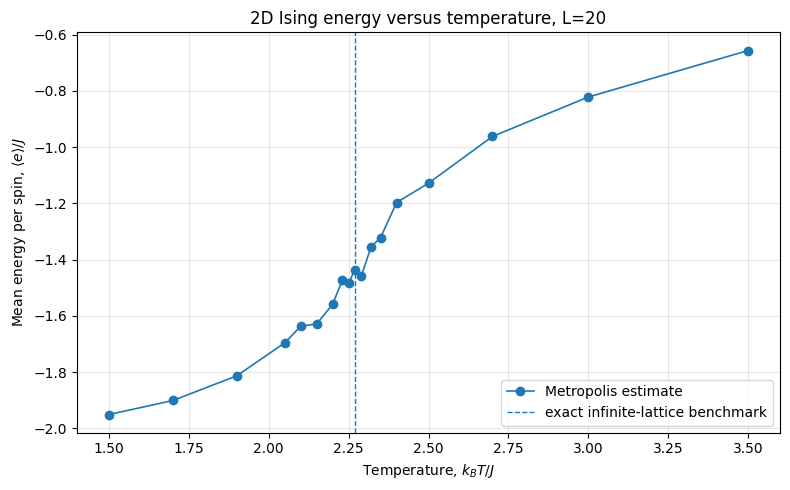

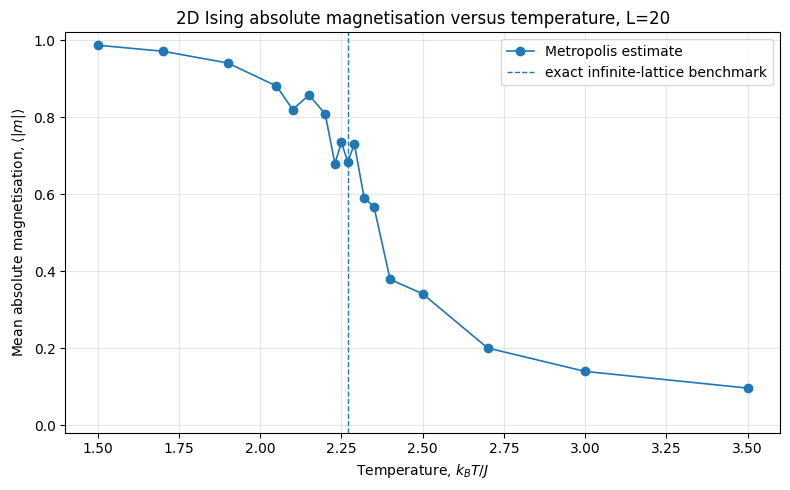

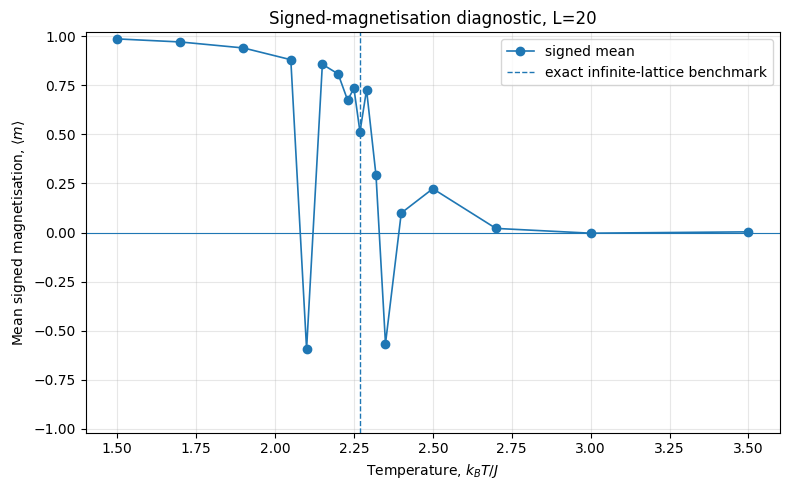

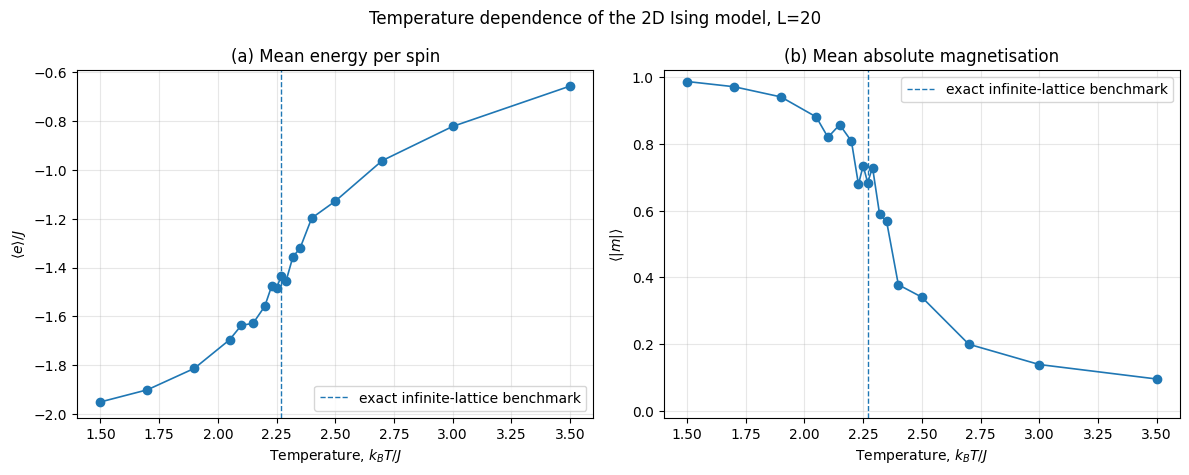

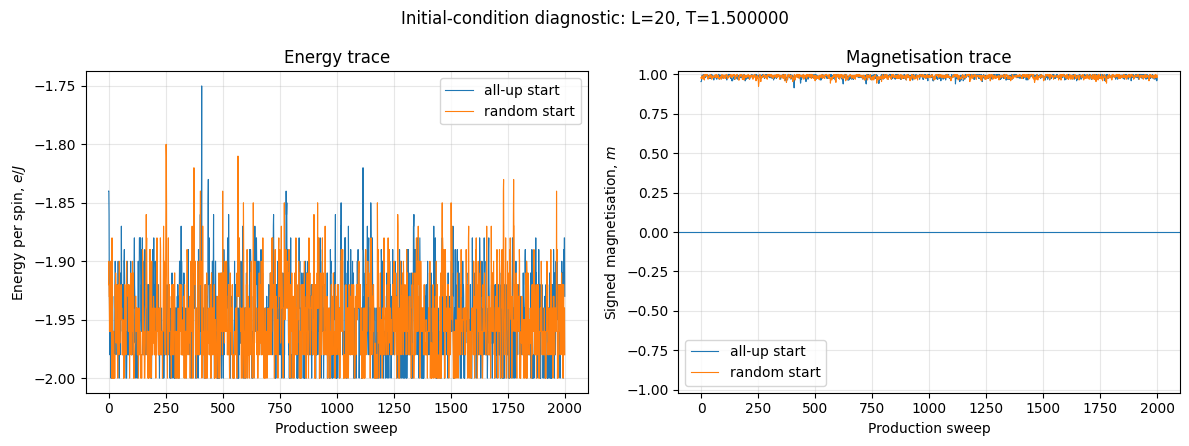

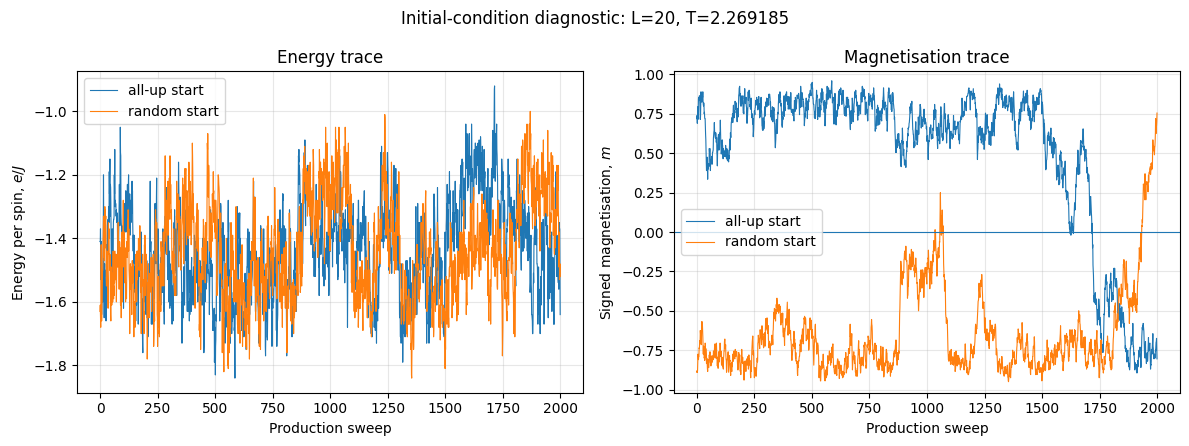

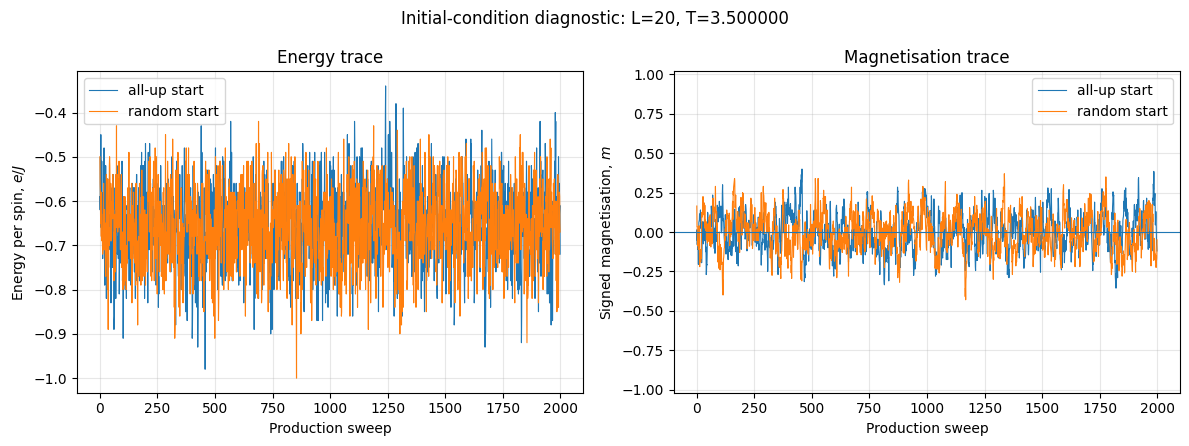

Saved figures:
  energy: outputs\day22\energy_per_spin_vs_temperature_L20.png
  absolute_magnetisation: outputs\day22\absolute_magnetisation_vs_temperature_L20.png
  signed_magnetisation_diagnostic: outputs\day22\signed_magnetisation_vs_temperature_L20_diagnostic.png
  combined: outputs\day22\energy_and_absolute_magnetisation_vs_temperature_L20.png


In [13]:
def mean_over_replicates(sweep: dict, key: str) -> np.ndarray:
    """Average one summary quantity over the replicate dimension."""
    values = np.asarray(sweep[key], dtype=float)
    if values.ndim != 2:
        raise ValueError(
            f"{key} must have shape (n_replicates, n_temperatures)."
        )

    return np.mean(values, axis=0)


def plot_temperature_observables(
    sweep: dict,
    output_dir: Path,
) -> dict:
    """Create and save separate and combined temperature curves."""
    temperatures = sweep["temperatures"]
    mean_e = mean_over_replicates(sweep, "mean_e")
    mean_m = mean_over_replicates(sweep, "mean_m")
    mean_abs_m = mean_over_replicates(sweep, "mean_abs_m")
    L = sweep["L"]

    paths = {
        "energy": output_dir / f"energy_per_spin_vs_temperature_L{L}.png",
        "absolute_magnetisation": (
            output_dir
            / f"absolute_magnetisation_vs_temperature_L{L}.png"
        ),
        "signed_magnetisation_diagnostic": (
            output_dir
            / f"signed_magnetisation_vs_temperature_L{L}_diagnostic.png"
        ),
        "combined": (
            output_dir
            / f"energy_and_absolute_magnetisation_vs_temperature_L{L}.png"
        ),
    }

    plt.figure(figsize=(8, 5))
    plt.plot(
        temperatures,
        mean_e,
        marker="o",
        linewidth=1.2,
        label="Metropolis estimate",
    )
    plt.axvline(
        TC_EXACT,
        linestyle="--",
        linewidth=1.0,
        label="exact infinite-lattice benchmark",
    )
    plt.xlabel(r"Temperature, $k_B T/J$")
    plt.ylabel(r"Mean energy per spin, $\langle e\rangle/J$")
    plt.title(f"2D Ising energy versus temperature, L={L}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(paths["energy"], dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(
        temperatures,
        mean_abs_m,
        marker="o",
        linewidth=1.2,
        label="Metropolis estimate",
    )
    plt.axvline(
        TC_EXACT,
        linestyle="--",
        linewidth=1.0,
        label="exact infinite-lattice benchmark",
    )
    plt.xlabel(r"Temperature, $k_B T/J$")
    plt.ylabel(r"Mean absolute magnetisation, $\langle |m|\rangle$")
    plt.title(f"2D Ising absolute magnetisation versus temperature, L={L}")
    plt.ylim(-0.02, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        paths["absolute_magnetisation"],
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(
        temperatures,
        mean_m,
        marker="o",
        linewidth=1.2,
        label="signed mean",
    )
    plt.axvline(
        TC_EXACT,
        linestyle="--",
        linewidth=1.0,
        label="exact infinite-lattice benchmark",
    )
    plt.axhline(0.0, linewidth=0.8)
    plt.xlabel(r"Temperature, $k_B T/J$")
    plt.ylabel(r"Mean signed magnetisation, $\langle m\rangle$")
    plt.title(f"Signed-magnetisation diagnostic, L={L}")
    plt.ylim(-1.02, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        paths["signed_magnetisation_diagnostic"],
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    figure, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

    axes[0].plot(temperatures, mean_e, marker="o", linewidth=1.2)
    axes[0].axvline(
        TC_EXACT,
        linestyle="--",
        linewidth=1.0,
        label="exact infinite-lattice benchmark",
    )
    axes[0].set_xlabel(r"Temperature, $k_B T/J$")
    axes[0].set_ylabel(r"$\langle e\rangle/J$")
    axes[0].set_title("(a) Mean energy per spin")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        temperatures,
        mean_abs_m,
        marker="o",
        linewidth=1.2,
    )
    axes[1].axvline(
        TC_EXACT,
        linestyle="--",
        linewidth=1.0,
        label="exact infinite-lattice benchmark",
    )
    axes[1].set_xlabel(r"Temperature, $k_B T/J$")
    axes[1].set_ylabel(r"$\langle |m|\rangle$")
    axes[1].set_title("(b) Mean absolute magnetisation")
    axes[1].set_ylim(-0.02, 1.02)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    figure.suptitle(f"Temperature dependence of the 2D Ising model, L={L}")
    figure.tight_layout()
    figure.savefig(paths["combined"], dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)

    return paths


def plot_initial_condition_diagnostics(
    sweep: dict,
    random_runs: list[dict],
    output_dir: Path,
) -> list[Path]:
    """Save energy and signed-magnetisation trace comparisons."""
    paths = []

    for random_run in random_runs:
        temperature = random_run["T"]
        temperature_index = int(
            np.argmin(np.abs(sweep["temperatures"] - temperature))
        )

        primary_e = (
            sweep["production_E"][0, temperature_index]
            / sweep["n_spins"]
        )
        primary_m = sweep["production_m"][0, temperature_index]
        random_e = random_run["production_E"] / random_run["n_spins"]
        random_m = random_run["production_m"]

        tag = f"{temperature:.3f}".replace(".", "p")
        path = output_dir / f"initial_condition_comparison_T{tag}.png"

        figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

        axes[0].plot(primary_e, linewidth=0.8, label="all-up start")
        axes[0].plot(random_e, linewidth=0.8, label="random start")
        axes[0].set_xlabel("Production sweep")
        axes[0].set_ylabel(r"Energy per spin, $e/J$")
        axes[0].set_title("Energy trace")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(primary_m, linewidth=0.8, label="all-up start")
        axes[1].plot(random_m, linewidth=0.8, label="random start")
        axes[1].axhline(0.0, linewidth=0.8)
        axes[1].set_xlabel("Production sweep")
        axes[1].set_ylabel(r"Signed magnetisation, $m$")
        axes[1].set_title("Magnetisation trace")
        axes[1].set_ylim(-1.02, 1.02)
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        figure.suptitle(
            f"Initial-condition diagnostic: "
            f"L={sweep['L']}, T={temperature:.6f}"
        )
        figure.tight_layout()
        figure.savefig(path, dpi=250, bbox_inches="tight")
        plt.show()
        plt.close(figure)

        paths.append(path)

    return paths


figure_paths = plot_temperature_observables(main_sweep, OUTPUT_DIR)
diagnostic_figure_paths = plot_initial_condition_diagnostics(
    main_sweep,
    random_start_runs,
    DIAGNOSTIC_DIR,
)

print("Saved figures:")
for name, path in figure_paths.items():
    print(f"  {name}: {path}")

### Provisional captions

**Source:** These captions describe the encoded simulation protocol and do not add unsupported uncertainty claims.

**`energy_per_spin_vs_temperature_L20.png`**

> **Mean energy per spin of the finite two-dimensional Ising model as a function of temperature.** Results use an $L=20$ periodic square lattice with $J=1$, $B=0$ and $k_B=1$. Each temperature is represented by one independently seeded Metropolis run with 1,000 burn-in sweeps followed by 2,000 production sweeps. The vertical line denotes the exact infinite-lattice critical-temperature benchmark and is not a fitted finite-size transition. Connecting segments are guides to the eye, and no final uncertainty intervals are claimed for this provisional single-seed result.

**`absolute_magnetisation_vs_temperature_L20.png`**

> **Mean absolute magnetisation per spin of the finite two-dimensional Ising model as a function of temperature.** The use of $\langle|m|\rangle$ preserves the magnitude of finite-system order when the positive and negative magnetisation sectors are symmetry-related. Signed $\langle m\rangle$ is retained separately as a mixing diagnostic. The vertical line marks the exact infinite-lattice benchmark, while the smooth change reflects finite-size rounding.

**`energy_and_absolute_magnetisation_vs_temperature_L20.png`**

> **Temperature dependence of energy and magnetic order in the finite two-dimensional Ising model.** Panel (a) shows the mean energy per spin and panel (b) the mean absolute magnetisation per spin for an $L=20$ periodic lattice simulated with independent, reproducibly seeded Metropolis runs. Each temperature used 1,000 burn-in and 2,000 production sweeps. The exact infinite-lattice critical temperature is shown as a benchmark in both panels. The finite system displays a rounded transition region rather than a singular change, and the single-seed points are presented without final uncertainty intervals.

## 13. Reproducible data and metadata

**Source:** This section implements the project requirement that every plotted point can be traced to saved parameters, seeds and raw arrays.

The compressed NPZ retains the full burn-in and production arrays. The CSV contains one convenient summary row per replicate and temperature. The JSON records physical conventions, protocol, seed mapping, benchmark, limitations and figure filenames.

In [14]:
def save_temperature_sweep(
    sweep: dict,
    output_dir: Path,
    figure_paths: dict,
    diagnostic_figure_paths: list[Path],
) -> dict:
    """Save full arrays, summary CSV and human-readable metadata."""
    L = sweep["L"]
    npz_path = output_dir / f"temperature_sweep_L{L}_full.npz"
    csv_path = output_dir / f"temperature_sweep_L{L}_summary.csv"
    metadata_path = output_dir / f"temperature_sweep_L{L}_metadata.json"

    np.savez_compressed(
        npz_path,
        temperatures=sweep["temperatures"],
        seeds=sweep["seeds"],
        L=sweep["L"],
        n_spins=sweep["n_spins"],
        J=sweep["J"],
        B=sweep["B"],
        k_B=sweep["k_B"],
        n_burn_sweeps=sweep["n_burn_sweeps"],
        n_production_sweeps=sweep["n_production_sweeps"],
        storage_interval=sweep["storage_interval"],
        initial_state=np.array(sweep["initial_state"]),
        elapsed_seconds=sweep["elapsed_seconds"],
        exact_infinite_lattice_Tc=TC_EXACT,
        initial_grids=sweep["initial_grid"],
        final_grids=sweep["final_grid"],
        burn_E=sweep["burn_E"],
        burn_m=sweep["burn_m"],
        burn_acceptance=sweep["burn_acceptance"],
        production_E=sweep["production_E"],
        production_E2=sweep["production_E2"],
        production_m=sweep["production_m"],
        production_m2=sweep["production_m2"],
        production_abs_m=sweep["production_abs_m"],
        production_acceptance=sweep["production_acceptance"],
        mean_E=sweep["mean_E"],
        mean_E2=sweep["mean_E2"],
        mean_e=sweep["mean_e"],
        mean_m=sweep["mean_m"],
        mean_m2=sweep["mean_m2"],
        mean_abs_m=sweep["mean_abs_m"],
        mean_acceptance=sweep["mean_acceptance"],
    )

    fieldnames = [
        "replicate",
        "temperature",
        "seed",
        "L",
        "n_spins",
        "J",
        "B",
        "k_B",
        "initial_state",
        "burn_in_sweeps",
        "production_sweeps",
        "storage_interval",
        "n_recorded_samples",
        "mean_total_energy",
        "mean_energy_squared",
        "mean_energy_per_spin",
        "mean_signed_magnetisation",
        "mean_magnetisation_squared",
        "mean_absolute_magnetisation",
        "mean_acceptance_fraction",
        "first_half_mean_energy_per_spin",
        "second_half_mean_energy_per_spin",
        "first_half_mean_absolute_magnetisation",
        "second_half_mean_absolute_magnetisation",
    ]

    with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()

        for replicate_index in range(sweep["n_replicates"]):
            for temperature_index, temperature in enumerate(
                sweep["temperatures"]
            ):
                e_trace = (
                    sweep["production_E"][
                        replicate_index,
                        temperature_index,
                    ]
                    / sweep["n_spins"]
                )
                abs_m_trace = sweep["production_abs_m"][
                    replicate_index,
                    temperature_index,
                ]
                e_first, e_second = split_half_means(e_trace)
                m_first, m_second = split_half_means(abs_m_trace)

                writer.writerow(
                    {
                        "replicate": replicate_index,
                        "temperature": f"{temperature:.9f}",
                        "seed": int(
                            sweep["seeds"][
                                replicate_index,
                                temperature_index,
                            ]
                        ),
                        "L": sweep["L"],
                        "n_spins": sweep["n_spins"],
                        "J": sweep["J"],
                        "B": sweep["B"],
                        "k_B": sweep["k_B"],
                        "initial_state": sweep["initial_state"],
                        "burn_in_sweeps": sweep["n_burn_sweeps"],
                        "production_sweeps": (
                            sweep["n_production_sweeps"]
                        ),
                        "storage_interval": sweep["storage_interval"],
                        "n_recorded_samples": (
                            sweep["n_production_sweeps"]
                        ),
                        "mean_total_energy": (
                            sweep["mean_E"][
                                replicate_index,
                                temperature_index,
                            ]
                        ),
                        "mean_energy_squared": (
                            sweep["mean_E2"][
                                replicate_index,
                                temperature_index,
                            ]
                        ),
                        "mean_energy_per_spin": (
                            sweep["mean_e"][
                                replicate_index,
                                temperature_index,
                            ]
                        ),
                        "mean_signed_magnetisation": (
                            sweep["mean_m"][
                                replicate_index,
                                temperature_index,
                            ]
                        ),
                        "mean_magnetisation_squared": (
                            sweep["mean_m2"][
                                replicate_index,
                                temperature_index,
                            ]
                        ),
                        "mean_absolute_magnetisation": (
                            sweep["mean_abs_m"][
                                replicate_index,
                                temperature_index,
                            ]
                        ),
                        "mean_acceptance_fraction": (
                            sweep["mean_acceptance"][
                                replicate_index,
                                temperature_index,
                            ]
                        ),
                        "first_half_mean_energy_per_spin": e_first,
                        "second_half_mean_energy_per_spin": e_second,
                        "first_half_mean_absolute_magnetisation": m_first,
                        "second_half_mean_absolute_magnetisation": m_second,
                    }
                )

    metadata = {
        "notebook": "22_Temperature_Sweep_Energy_and_Magnetisation.ipynb",
        "purpose": (
            "Provisional single-seed temperature sweep for energy "
            "and magnetisation."
        ),
        "physical_conventions": {
            "lattice": "L x L periodic square lattice",
            "J": sweep["J"],
            "B": sweep["B"],
            "k_B": sweep["k_B"],
            "sweep_definition": (
                "Exactly L^2 random single-spin attempts with replacement."
            ),
        },
        "protocol": {
            "L": sweep["L"],
            "n_spins": sweep["n_spins"],
            "temperatures": [
                float(value) for value in sweep["temperatures"]
            ],
            "n_replicates": sweep["n_replicates"],
            "seeds": sweep["seeds"].astype(int).tolist(),
            "initial_state": sweep["initial_state"],
            "burn_in_sweeps": sweep["n_burn_sweeps"],
            "production_sweeps": sweep["n_production_sweeps"],
            "storage_interval": sweep["storage_interval"],
            "elapsed_seconds": sweep["elapsed_seconds"],
        },
        "benchmark": {
            "description": "Exact zero-field infinite square-lattice value",
            "T_c": float(TC_EXACT),
            "role": "Reference line, not a fitted finite-size transition",
        },
        "limitations": [
            "One primary seed per temperature.",
            "No final confidence intervals.",
            "Successive production values may be autocorrelated.",
            "Susceptibility and specific heat are deferred to 23 July.",
        ],
        "files": {
            "npz": npz_path.name,
            "csv": csv_path.name,
            "figures": {
                name: path.name for name, path in figure_paths.items()
            },
            "diagnostic_figures": [
                str(path.relative_to(output_dir))
                for path in diagnostic_figure_paths
            ],
        },
    }

    with metadata_path.open("w", encoding="utf-8") as metadata_file:
        json.dump(metadata, metadata_file, indent=2)

    return {
        "npz": npz_path,
        "csv": csv_path,
        "metadata": metadata_path,
    }


def save_random_start_diagnostics(
    runs: list[dict],
    output_dir: Path,
) -> Path:
    """Save the three independent random-start diagnostic runs."""
    path = output_dir / "initial_condition_diagnostics.npz"

    np.savez_compressed(
        path,
        temperatures=np.array([run["T"] for run in runs]),
        seeds=np.array([run["seed"] for run in runs], dtype=np.int64),
        production_E=np.stack([run["production_E"] for run in runs]),
        production_E2=np.stack([run["production_E2"] for run in runs]),
        production_m=np.stack([run["production_m"] for run in runs]),
        production_m2=np.stack([run["production_m2"] for run in runs]),
        production_abs_m=np.stack(
            [run["production_abs_m"] for run in runs]
        ),
        production_acceptance=np.stack(
            [run["production_acceptance"] for run in runs]
        ),
        mean_e=np.array([run["mean_e"] for run in runs]),
        mean_m=np.array([run["mean_m"] for run in runs]),
        mean_abs_m=np.array([run["mean_abs_m"] for run in runs]),
        mean_acceptance=np.array(
            [run["mean_acceptance"] for run in runs]
        ),
    )

    return path


saved_paths = save_temperature_sweep(
    main_sweep,
    OUTPUT_DIR,
    figure_paths,
    diagnostic_figure_paths,
)
diagnostic_data_path = save_random_start_diagnostics(
    random_start_runs,
    DIAGNOSTIC_DIR,
)

with np.load(saved_paths["npz"], allow_pickle=False) as reloaded:
    for key in (
        "temperatures",
        "seeds",
        "production_E",
        "production_E2",
        "production_m",
        "production_m2",
        "production_abs_m",
        "production_acceptance",
        "mean_e",
        "mean_m",
        "mean_abs_m",
        "mean_acceptance",
    ):
        assert np.array_equal(reloaded[key], main_sweep[key])

print("Save/reload integrity test passed.")
print("Saved data files:")
for name, path in saved_paths.items():
    print(f"  {name}: {path}")
print(f"  random-start diagnostics: {diagnostic_data_path}")

Save/reload integrity test passed.
Saved data files:
  npz: outputs\day22\temperature_sweep_L20_full.npz
  csv: outputs\day22\temperature_sweep_L20_summary.csv
  metadata: outputs\day22\temperature_sweep_L20_metadata.json
  random-start diagnostics: outputs\day22\diagnostics\initial_condition_diagnostics.npz


## 14. Validation summary

**Source:** Krauth, printed pp. 235–236 and Figs. 5.16–5.17, for expected temperature-dependent energy and magnetic order.

The generated table below contains the actual primary-run results. The required qualitative checks are:

- low-temperature energy is more negative than high-temperature energy;
- low-temperature \(\langle|m|\rangle\) exceeds the high-temperature value;
- all energy, magnetisation and acceptance values remain in physical ranges;
- the most rapid change is rounded and occurs near the infinite-lattice benchmark;
- signed \(\langle m\rangle\) is interpreted as a sector/mixing diagnostic rather than the main finite-system order parameter.

In [15]:
print(
    f"{'T':>10} {'mean e':>12} {'mean m':>12} "
    f"{'mean |m|':>12} {'accept':>10}"
)
print("-" * 62)

for temperature_index, temperature in enumerate(MAIN_TEMPERATURES):
    print(
        f"{temperature:>10.6f} "
        f"{main_sweep['mean_e'][0, temperature_index]:>12.5f} "
        f"{main_sweep['mean_m'][0, temperature_index]:>12.5f} "
        f"{main_sweep['mean_abs_m'][0, temperature_index]:>12.5f} "
        f"{main_sweep['mean_acceptance'][0, temperature_index]:>10.5f}"
    )

assert main_sweep["mean_abs_m"][0, 0] > main_sweep["mean_abs_m"][0, -1]
assert main_sweep["mean_e"][0, 0] < main_sweep["mean_e"][0, -1]
assert np.all((-2.0 <= main_sweep["mean_e"]) & (main_sweep["mean_e"] <= 2.0))
assert np.all(
    (0.0 <= main_sweep["mean_acceptance"])
    & (main_sweep["mean_acceptance"] <= 1.0)
)

print("\nEnd-of-day physical trend and range checks passed.")

         T       mean e       mean m     mean |m|     accept
--------------------------------------------------------------
  1.500000     -1.95107      0.98655      0.98655    0.01347
  1.700000     -1.90119      0.97091      0.97091    0.02842
  1.900000     -1.81338      0.94037      0.94037    0.05627
  2.050000     -1.69620      0.88054      0.88054    0.09665
  2.100000     -1.63697     -0.59348      0.81949    0.11687
  2.150000     -1.62888      0.85732      0.85732    0.12102
  2.200000     -1.55866      0.80788      0.80788    0.14498
  2.230000     -1.47384      0.67439      0.67866    0.17627
  2.250000     -1.48389      0.73444      0.73455    0.17407
  2.269185     -1.43669      0.51259      0.68397    0.19138
  2.290000     -1.45707      0.72732      0.72906    0.18411
  2.320000     -1.35542      0.29098      0.58959    0.22211
  2.350000     -1.32142     -0.56562      0.56747    0.23634
  2.400000     -1.19722      0.09942      0.37818    0.28478
  2.500000     -1.1281

## 15. Limitations and 23 July handover

**Source:** Krauth, printed p. 251, for slow local-update dynamics and the small number of effectively independent magnetisation excursions near criticality.

This notebook provides an end-to-end reproducible temperature sweep, but its limitations remain explicit:

- one primary seed at each temperature;
- autocorrelation between successive production measurements;
- possible slow global mixing between positive and negative magnetisation sectors;
- one lattice size, so no finite-size-scaling conclusion;
- no final uncertainty interval or phase-boundary estimate.

On 23 July, multiple seeds will be added and the saved $E^2$ and $m^2$ arrays will support susceptibility and specific-heat calculations with a correlation-aware uncertainty method.

## References

- Krauth, W., *Statistical Mechanics: Algorithms and Computations*. Section 5.1.2, printed pp. 234–236; Section 5.2.1, printed pp. 250–252; especially Figs. 5.14–5.17 and Algorithm 5.7.
- Tong, D., *Statistical Physics*, Chapter 5. Section 5.2, printed pp. 147–148; Section 5.2.3, printed p. 154; Section 5.3.2, printed pp. 157–158; Section 5.3.4, printed pp. 165–166.
- Metropolis, N., Rosenbluth, A. W., Rosenbluth, M. N., Teller, A. H. and Teller, E. (1953), “Equation of State Calculations by Fast Computing Machines”, *Journal of Chemical Physics*, **21**, 1087–1092.
- Onsager, L. (1944), “Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition”, *Physical Review*, **65**, 117–149.